In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
# Set default figuresize and font size and labelsize for plots
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 25
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'STIXGeneral'

from glob import glob

In [2]:
def calculate_PAO_spectrum(e_eV):
    """
    Calculate the CR flux measured by PAO in 10 ** 17 eV < E < 10 ** 20 eV
    with the SD-750 and SD-1500.
    The formula of the spectrum is Equation (13) of
    Abreu et al., Eur. Phys. J. C 81, 966 (2021)
    (https://doi.org/10.1140/epjc/s10052-021-09700-w)
    """


    j_0 = 1.309e-18 # km^-2 yr^-1 sr^-1 eV^-1
    e_0 = 10 ** 18.5 # eV
    omega_01, omega_12, omega_23, omega_34 = 0.43, 0.05, 0.05, 0.05
    g_0, g_1, g_2, g_3, g_4 = 2.64, 3.298, 2.52, 3.08, 5.2
    e_01, e_12, e_23, e_34 = 1.24e17, 4.9e18, 1.4e19, 4.7e19 # eV

    j = j_0 * (e_eV/e_0) ** (-g_0) \
            * (1 + (e_eV/e_01) ** (1/omega_01)) ** ((g_0-g_1) * omega_01) \
            * (1 + (e_eV/e_12) ** (1/omega_12)) ** ((g_1-g_2) * omega_12) \
            * (1 + (e_eV/e_23) ** (1/omega_23)) ** ((g_2-g_3) * omega_23) \
            * (1 + (e_eV/e_34) ** (1/omega_34)) ** ((g_3-g_4) * omega_34) \
            / (1 + (e_0/e_01)  ** (1/omega_01)) ** ((g_0-g_1) * omega_01) \
            / (1 + (e_0/e_12)  ** (1/omega_12)) ** ((g_1-g_2) * omega_12) \
            / (1 + (e_0/e_23)  ** (1/omega_23)) ** ((g_2-g_3) * omega_23) \
            / (1 + (e_0/e_34)  ** (1/omega_34)) ** ((g_3-g_4) * omega_34)

    return j

# SWF quantification

In [3]:
def plot_loghist(x, bins, label, alpha, density=False,range=None):
    """
    Plot histogram in log scale
    """
    hist, bins = np.histogram(x, bins=bins, range=range)
    logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
    plt.hist(x, bins=logbins, label=label, alpha=alpha, density=density)
    plt.xscale('log')


# path_sim = sorted(glob("/pbs/home/j/jlavoisier/pipeline_lab/SWF_quant/out_files/batch/adc*"))
path_sim = sorted(glob("/sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_*SWF*"))


chi2_sims = np.array([])
n_ant_trig_sims = np.array([])
theta_sims = np.array([])
phi_sims = np.array([])
theta_true = np.array([])
phi_true = np.array([])

for i in range(len(path_sim)):
    file_sims = np.load(path_sim[i])
    print("Number of simulated events in file ", path_sim[i], " : ", len(file_sims[0]))
    n_ant_trig_sims = np.append(n_ant_trig_sims, file_sims[0])
    chi2_sims = np.append(chi2_sims, file_sims[1])
    theta_sims = np.append(theta_sims, file_sims[2])
    phi_sims = np.append(phi_sims, file_sims[3])
    theta_true = np.append(theta_true, file_sims[4])
    phi_true = np.append(phi_true, file_sims[5])

print("Number of simulated events processed : ", len(chi2_sims))


Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0001_chi2_SWF_n_ant.npy  :  0
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0002_chi2_SWF_n_ant.npy  :  0
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0003_chi2_SWF_n_ant.npy  :  0
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0004_chi2_SWF_n_ant.npy  :  146
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0005_chi2_SWF_n_ant.npy  :  456
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0006_chi2_SWF_n_ant.npy  :  691


Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0007_chi2_SWF_n_ant.npy  :  358
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0008_chi2_SWF_n_ant.npy  :  0
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0009_chi2_SWF_n_ant.npy  :  22
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0010_chi2_SWF_n_ant.npy  :  280
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0011_chi2_SWF_n_ant.npy  :  601
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0012_chi2_SWF_n_ant.npy  :  761
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0013_c

In [4]:
# For energy import

path = f"/sps/grand/jlavoisier/code/quantification/check_sims/out_files/simsGP300NJ_theta_n_ant_energy.npy"

file_sims = np.load(path)

theta_tot = file_sims[0]
phi_tot = file_sims[1]
n_ant_trig_tot = file_sims[2]
energy_tot = file_sims[3]

theta = theta_tot[n_ant_trig_tot >= 5]
phi = phi_tot[n_ant_trig_tot >= 5]
energy = energy_tot[n_ant_trig_tot >= 5]

print(len(theta_true))
print(len(theta))

3496
3496


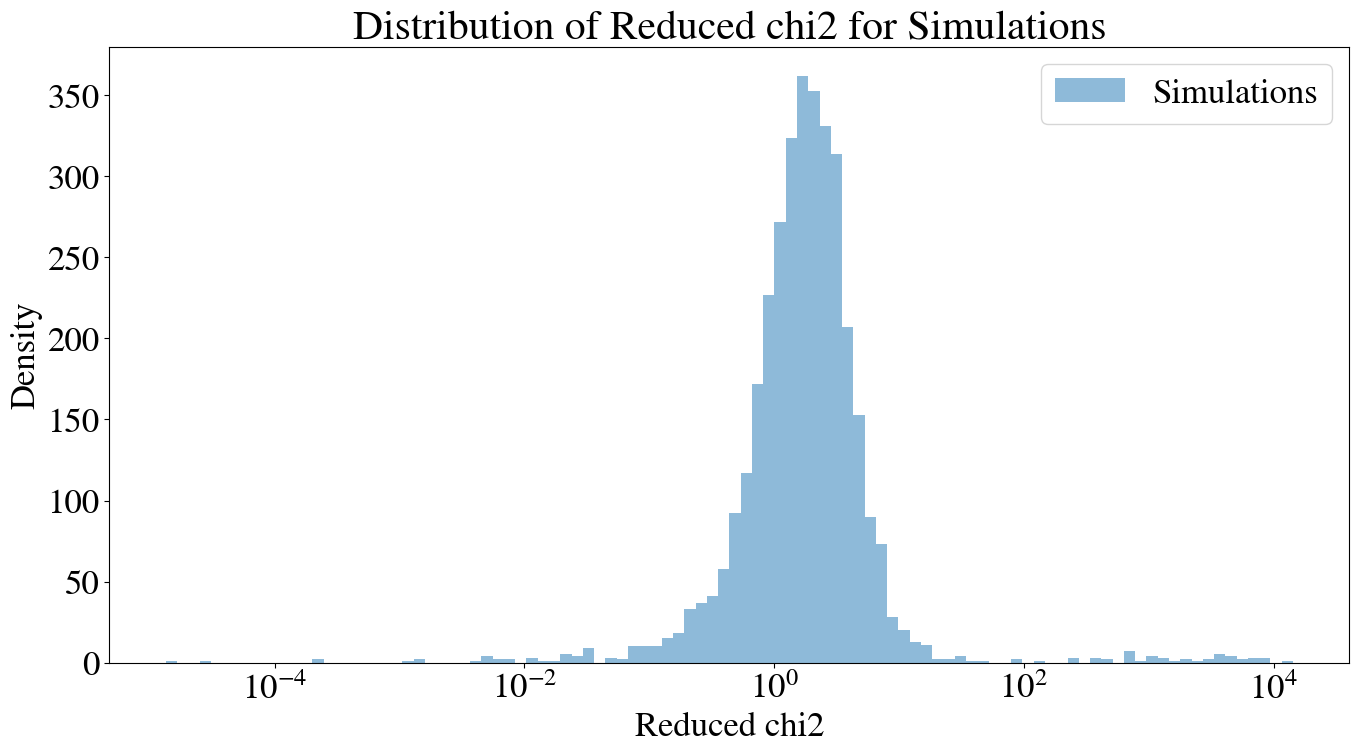

Fraction of events with reduced chi2 < 1000 :  0.9914187643020596


In [5]:
plot_loghist(chi2_sims, 
             bins=100, 
             alpha=0.5, 
             label='Simulations', 
            #  density=True
             )
plt.xlabel('Reduced chi2')
plt.ylabel('Density')
plt.title('Distribution of Reduced chi2 for Simulations')
plt.legend()
plt.show()

print("Fraction of events with reduced chi2 < 1000 : ", len(chi2_sims[chi2_sims<1000])/len(chi2_sims))

In [6]:
chi2_sims = np.array([])

for i in range(len(path_sim)):
    file_sims = np.load(path_sim[i])
    chi2_sims = np.append(chi2_sims, file_sims[1])

print("Number of simulated events processed : ", len(chi2_sims))

Number of simulated events processed :  3496


In [7]:
parasites_chi2_SWF_RUN = np.load(f"/sps/grand/jlavoisier/code/quantification/check_data/data/chi2_SWF_parasites.npy",
                    allow_pickle=True
                    ).item()
parasites_theta_RUN = np.load("/sps/grand/jlavoisier/code/quantification/check_data/data/theta_parasites.npy",
                    allow_pickle=True
                    ).item()
parasites_phi_RUN = np.load("/sps/grand/jlavoisier/code/quantification/check_data/data/phi_parasites.npy",
                    allow_pickle=True
                    ).item()


RUNs = np.array(list(parasites_chi2_SWF_RUN.keys()))


parasites_SWF_chi2 = np.array([])
parasites_theta = np.array([])
parasites_phi = np.array([])

for run in RUNs:
    parasites_SWF_chi2 = np.concatenate((parasites_SWF_chi2, parasites_chi2_SWF_RUN[run]))
    parasites_theta = np.concatenate((parasites_theta, parasites_theta_RUN[run]))
    parasites_phi = np.concatenate((parasites_phi, parasites_phi_RUN[run]))

print("Number of parasites events processed in chi2: ", len(parasites_SWF_chi2))
print("Number of parasites events processed in theta: ", len(parasites_theta))

mask_zenith = (parasites_theta*180/np.pi >= 60) & (parasites_theta*180/np.pi <= 88)
mask_mine = (parasites_phi*180/np.pi >= 280) & (parasites_phi*180/np.pi <= 315)

Number of parasites events processed in chi2:  5455335
Number of parasites events processed in theta:  5455335


In [8]:

# Weights per bin
weights_energy_events = np.zeros(len(energy))
for i in range(len(energy)):
    weights_energy_events[i] = calculate_PAO_spectrum(energy[i] * 1e9) # The weight for the energy bin

weights_energy_events = calculate_PAO_spectrum(energy * 1e9)

weights_zenith_events = np.sin(theta * np.pi / 180) * np.cos(theta * np.pi / 180) # The weight for the zenith bin

weights_events = weights_energy_events * weights_zenith_events

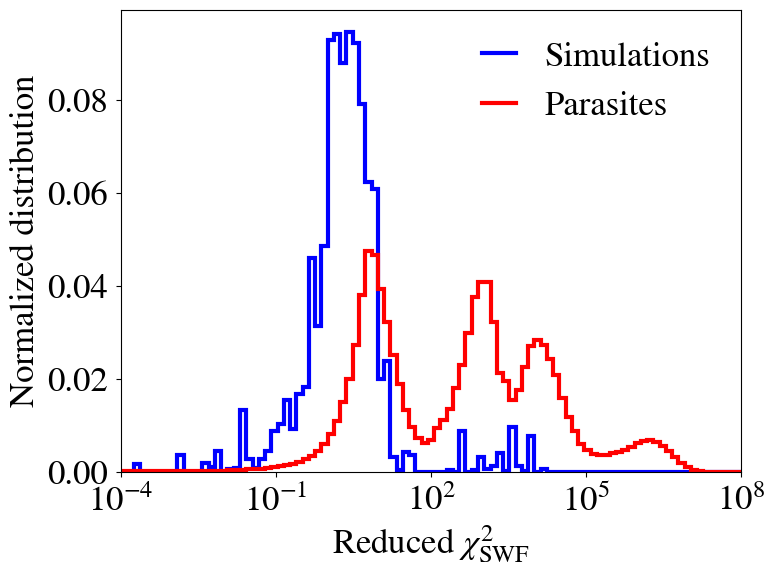

In [22]:
logbins = np.logspace(-4, 8, 100)

fig = plt.figure(figsize=(8, 6))

hist_chi2_sims, _ = np.histogram(chi2_sims, 
                                 bins=logbins,
                                 weights=weights_events
                                 )
norm_hist_chi2_sims = hist_chi2_sims / np.sum(weights_events)

plt.stairs(norm_hist_chi2_sims, 
           logbins, 
           label='Simulations', 
        #    alpha=0.5, 
           linewidth=3,
           color='blue'
           )

hist_chi2_data, _ = np.histogram(parasites_SWF_chi2, bins=logbins)
norm_hist_chi2_data = hist_chi2_data / np.sum(hist_chi2_data)
plt.stairs(norm_hist_chi2_data, 
           logbins, 
           label='Parasites', 
        #    alpha=0.5, 
           linewidth=3,
           color='red'
           )

plt.xlabel(r'Reduced $\chi^2_{\rm SWF}$')
plt.ylabel('Normalized distribution')
plt.xscale('log')
plt.xlim(1e-4, 1e8)
# plt.title(r'Normalized distribution of Reduced $\chi^2_{\rm SWF}$')
plt.legend(frameon=False,
           handlelength=1
           )
plt.tick_params(axis='both', 
                    # labelsize=23,
                    # direction="in",
                    pad=6
                    )

plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/SWF_chi2_distrib_total.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )
plt.show()

In [ ]:
chi2_limit = np.logspace(-4,8, 500)

loss_rate = 1 - np.array([len(chi2_sims[chi2_sims<chi2_limit[i]])/len(chi2_sims) for i in range(len(chi2_limit))])
cut_efficency = 1 -np.array([len(parasites_SWF_chi2[parasites_SWF_chi2<chi2_limit[i]])/len(parasites_SWF_chi2) for i in range(len(chi2_limit))])

fig = plt.figure(figsize=(8, 6))
plt.plot(chi2_limit, 
         100*loss_rate, 
         label=r"Loss rate $\ell_{\rm CR, SWF}$",
         linewidth=3
         )

plt.plot(chi2_limit, 
         100*cut_efficency, 
         label=r"Cut efficiency $\epsilon_{\rm cut, SWF}$",
         linewidth=3
         )

index_first_99 = np.where(loss_rate < 0.01)[0][0]
plt.plot(chi2_limit[index_first_99]+np.zeros(50),
         np.linspace(0, 100*cut_efficency[index_first_99], 50),
         color='black',
         linestyle='-.',
        #  label=r"$\epsilon_{\rm cut, SWF}$ for $\ell_{\rm CR, SWF}$ < 1%"
         )
plt.plot(chi2_limit[:index_first_99],
         100*cut_efficency[index_first_99]+np.zeros(len(chi2_limit[:index_first_99])),
         linestyle='-.',
         color='black',
        #  label=r"Cut eff for $\ell$ < 1%: {:.2f}%".format(100*cut_efficency[index_first_99])
         )


# plt.annotate(f"{100*cut_efficency[index_first_99]:.2f}%",
#              xy=(0.8, 0.9),
#              xytext=(1e-2, 35),
#              fontsize=23
#              )
print(f"Cut efficiency for SWF for loss rate = {100*loss_rate[index_first_99]:.2f} < 1% : {100*cut_efficency[index_first_99]:.2f}%")

# plt.annotate(r"$\ell_{\rm CR, SWF} < 1\%$",
#              xy=(0.8, 0.9),
#              xytext=(1e4, 10),
#              fontsize=23
#              )
print(f"Chi2 limit for SWF for loss rate < 1% : {chi2_limit[index_first_99]:.2e}")




plt.xlabel(r"$\chi^2_{\rm SWF, cut}$ threshold parameter",
            # fontsize=27
            )
plt.xscale('log')
plt.ylabel("Percentage (%)", 
        #    fontsize=27
           )
plt.xlim(1e-4, 1e8)
plt.ylim(0,100)

plt.legend(
        #    fontsize=20,
           loc="upper right",
           frameon=False,
           handlelength=1
           )

plt.tick_params(axis='both', 
                    # labelsize=23,
                    # direction="in",
                    pad=6
                    )

plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/SWF_loss_rate_total.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )
plt.show()

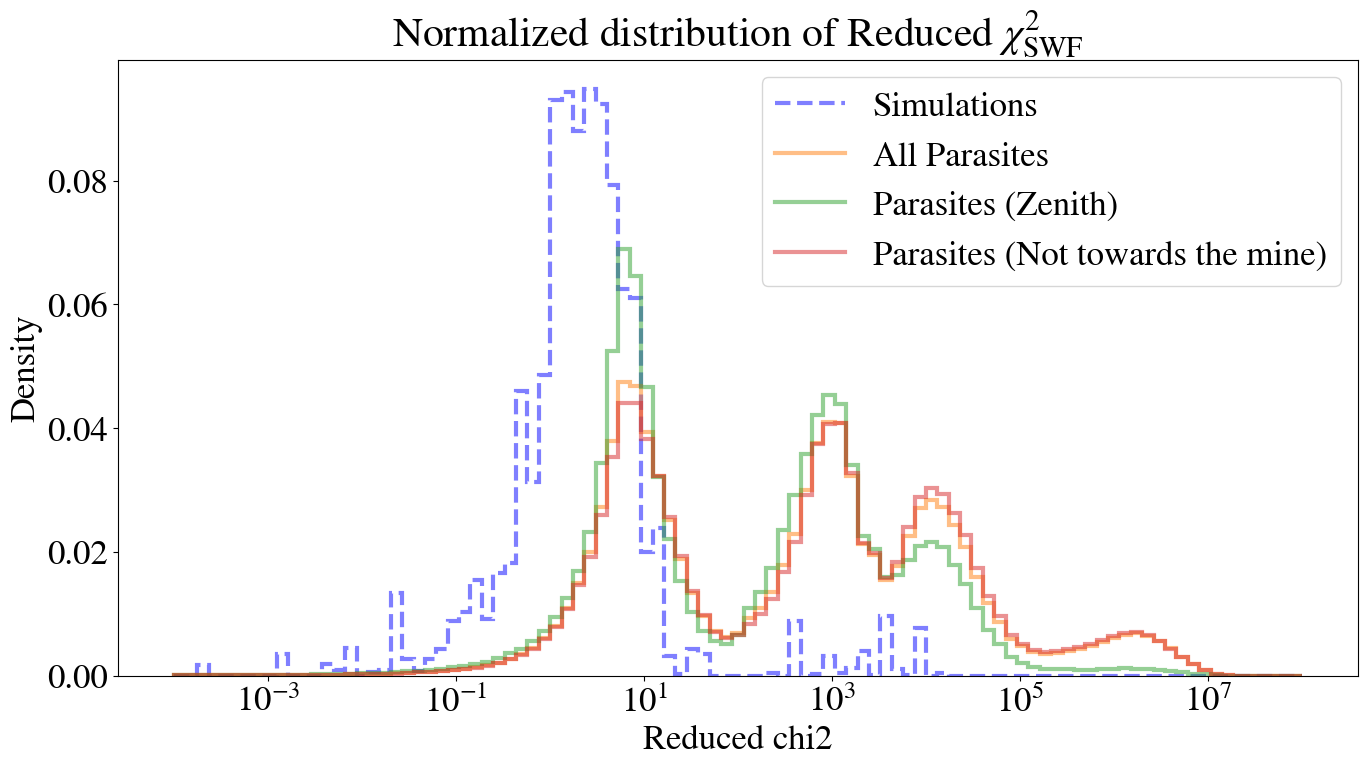

In [11]:
logbins = np.logspace(-4, 8, 100)

plt.stairs(norm_hist_chi2_sims, 
           logbins, 
           label='Simulations', 
           alpha=0.5, 
           color='blue',
           linewidth=3,
           linestyle='--'
           )

plt.stairs(norm_hist_chi2_data, 
           logbins, 
           label='All Parasites', 
           alpha=0.5, 
           color='tab:orange',
           linewidth=3
           )

hist_chi2_zenith, _ = np.histogram(parasites_SWF_chi2[mask_zenith], bins=logbins)
norm_hist_chi2_zenith = hist_chi2_zenith / np.sum(hist_chi2_zenith)
plt.stairs(norm_hist_chi2_zenith, 
           logbins, 
           label='Parasites (Zenith)', 
           alpha=0.5, 
           color='tab:green',
           linewidth=3
           )

hist_chi2_mine, _ = np.histogram(parasites_SWF_chi2[~mask_mine], bins=logbins)
norm_hist_chi2_mine = hist_chi2_mine / np.sum(hist_chi2_mine)
plt.stairs(norm_hist_chi2_mine, 
           logbins, 
           label='Parasites (Not towards the mine)', 
           alpha=0.5, 
           color='tab:red',
           linewidth=3
           )


plt.xlabel('Reduced chi2')
plt.ylabel('Density')
plt.xscale('log')
plt.title(r'Normalized distribution of Reduced $\chi^2_{\rm SWF}$')
plt.legend()
plt.show()

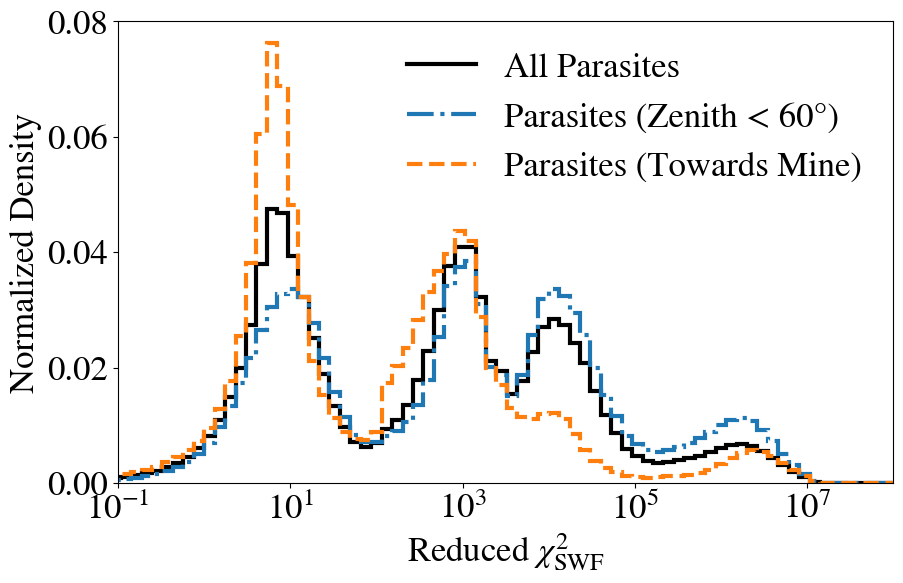

In [12]:
fig = plt.figure(figsize=(10, 6))

plt.stairs(norm_hist_chi2_data, 
           logbins, 
           label='All Parasites', 
        #    alpha=0.5, 
           color='black',
           linewidth=3
           )

hist_chi2_zenith, _ = np.histogram(parasites_SWF_chi2[~mask_zenith], bins=logbins)
norm_hist_chi2_zenith = hist_chi2_zenith / np.sum(hist_chi2_zenith)
plt.stairs(norm_hist_chi2_zenith, 
           logbins, 
           label='Parasites (Zenith < 60°)', 
        #    alpha=0.5, 
           color='tab:blue',
           linewidth=3,
           linestyle='-.'
           )

hist_chi2_mine, _ = np.histogram(parasites_SWF_chi2[mask_mine], bins=logbins)
norm_hist_chi2_mine = hist_chi2_mine / np.sum(hist_chi2_mine)
plt.stairs(norm_hist_chi2_mine, 
           logbins, 
           label='Parasites (Towards Mine)', 
        #    alpha=0.5, 
           color='tab:orange',
           linewidth=3,
           linestyle='--'
           )

plt.xlabel(r'Reduced $\chi^2_{\rm SWF}$')
plt.ylabel('Normalized Density')
plt.xscale('log')
plt.xlim(1e-1, 1e8)
# plt.title(r'Normalized distribution of Reduced $\chi^2_{\rm SWF}$')
plt.legend(frameon=False)
plt.show()

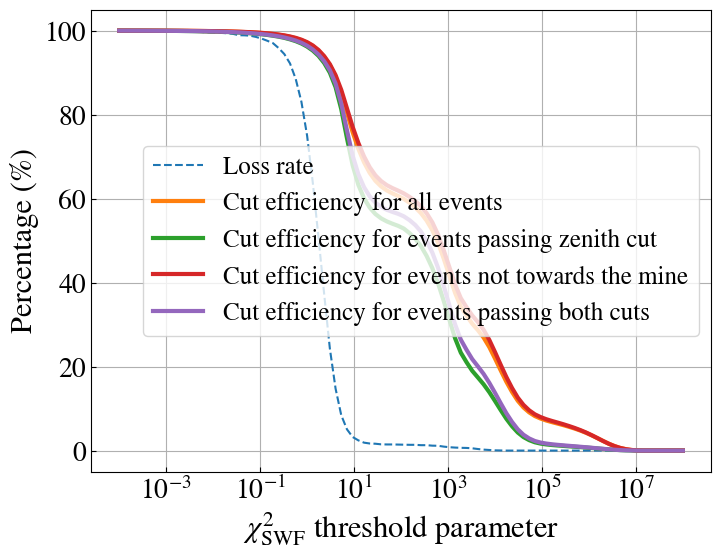

In [13]:


cut_efficency_zenith = 1 - np.array([np.sum(parasites_SWF_chi2[mask_zenith] <chi2_limit[i])/len(parasites_SWF_chi2[mask_zenith]) for i in range(len(chi2_limit))])
cut_efficency_mine = 1 - np.array([np.sum(parasites_SWF_chi2[~mask_mine] <chi2_limit[i])/len(parasites_SWF_chi2[~mask_mine]) for i in range(len(chi2_limit))])
cut_efficency_both = 1 - np.array([np.sum(parasites_SWF_chi2[np.logical_and(mask_zenith, ~mask_mine)] <chi2_limit[i])/len(parasites_SWF_chi2[np.logical_and(mask_zenith, ~mask_mine)]) for i in range(len(chi2_limit))])

fig = plt.figure(figsize=(8, 6))
plt.plot(chi2_limit, 
         100*loss_rate, 
         label=r"Loss rate",
         linestyle='--',
         )

plt.plot(chi2_limit, 
         100*cut_efficency, 
         label=r"Cut efficiency for all events",
         linewidth=3
         )

plt.plot(chi2_limit, 
         100*cut_efficency_zenith, 
         label=r"Cut efficiency for events passing zenith cut",
         linewidth=3
         )

plt.plot(chi2_limit, 
         100*cut_efficency_mine, 
         label=r"Cut efficiency for events not towards the mine",
         linewidth=3
         )

plt.plot(chi2_limit, 
         100*cut_efficency_both, 
         label=r"Cut efficiency for events passing both cuts",
         linewidth=3
         )


plt.xlabel(r"$\chi^2_{\rm SWF}$ threshold parameter",
            fontsize=22)
plt.xscale('log')
plt.ylabel("Percentage (%)", 
           fontsize=22)
plt.legend(fontsize=18)
plt.tick_params(axis='both', 
                    labelsize=20,
                    direction="in"
                    )
plt.grid()
plt.show()

## SWF vs PWF

In [14]:
parasites_chi2_PWF_RUN = np.load(f"/sps/grand/jlavoisier/code/quantification/check_data/data/chi2_PWF_parasites.npy",
                    allow_pickle=True
                    ).item()

parasites_PWF_chi2 = np.array([])

for run in RUNs:
    parasites_PWF_chi2 = np.concatenate((parasites_PWF_chi2, parasites_chi2_PWF_RUN[run]))


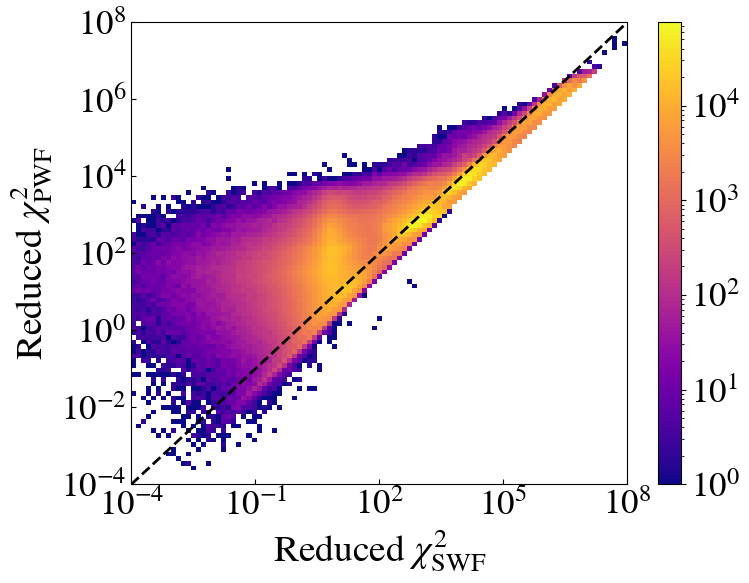

In [15]:
fig = plt.figure(figsize=(8,6))

plt.hist2d(parasites_SWF_chi2,
           parasites_PWF_chi2,
           bins=[np.logspace(-4, 8, 100),
                 np.logspace(-4, 8, 100)],
           norm=mpl.colors.LogNorm(),
           cmap='plasma'
           )

plt.plot([1e-4, 1e8], 
         [1e-4, 1e8], 
         color='black', 
         linestyle='--', 
         linewidth=2
         )

plt.colorbar()

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Reduced $\chi^2_{\rm SWF}$',
           fontsize=27
           )
plt.ylabel(r'Reduced $\chi^2_{\rm PWF}$',
           fontsize=27
           )
plt.tick_params(axis="both",
                direction="in",
                labelsize=25
                )

# add on the sides the distributions